# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 62 en 63     |  |
| :-------------|:-------------|
| Querijn Sanson| 6562507 |
| Eline Serpenti| 6506690 |
| Student naam 3| Student Studienummer 3 |
| Planning Groep: XX     |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1 | Tijdstip |
| Mijlpaal 2 | Tijdstip |
| groep aanwezig 1| Tijdspanne |
| groep aanwezig 2| Tijdspanne |
| Pauze 1| Tijdspanne |
| Pauze 2| Tijdspanne |

## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="condensator.jpeg" alt="schets student 1" width="400"/>

In [1]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!

epsilon_r_karton = 2.2  # F/m
epsilon0 = 8.854e-12   # F/m
A = 0.002        # m^2
d =  0.001      # m


def berekencondensator(epsilon0, epsilon_r, A, d):
    C = epsilon0* epsilon_r* A / d
    return C
C = berekencondensator(epsilon0, epsilon_r_karton, A, d)
print(C)

# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

3.89576e-11


In [2]:
import numpy as np

# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.
def bepaalcapaciteit(U_top, R_shunt, f):
    return U_top/(R_shunt* 16* np.pi *f )
# C = [functieNaam(2.0), functieNaam(4.7),functieNaam(1.2)]
U_top1 = 0.61
R_shunt1 = 1e3    # ohm
f1 = 100e3  #Hz
C_bepaald = bepaalcapaciteit(U_top1, R_shunt1, f1 ) * 10**12

print(f"Berekende capaciteit plaatcondensator groep XX is {C_bepaald:.1f} pF")



Berekende capaciteit plaatcondensator groep XX is 121.4 pF


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](osciloscoop.jpeg)


### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep Inhaal | 185 pF | 0.37 V | 0.61 V |121 pF |

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](schetsen.jpeg)


## Opdracht 3: Welke sensor gaan jullie maken?

Pas deze tekst aan: Wij gaan een sensor maken die afstand meet.

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](uitgewerkte_schets.jpeg)

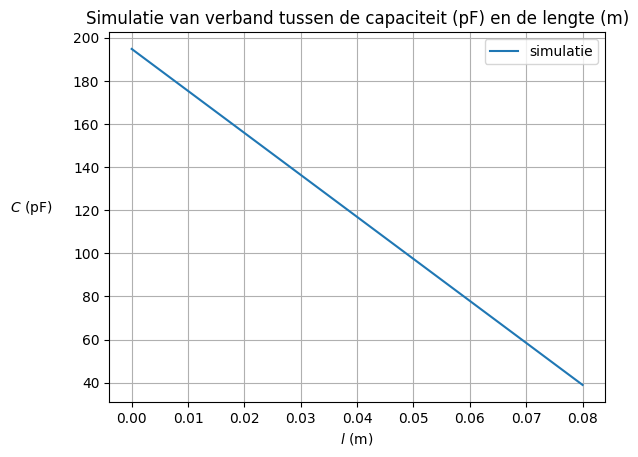

In [3]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.
import matplotlib.pyplot as plt
import numpy as np
# we gaan het effectieve oppervlak varieeren door de lengte te varieeren.
l = 0.1
l_varieërend = np.linspace(0, 0.08, 16) # m
b = 0.1     # m
A_varieert = b *( 0.1-l_varieërend)

# functie
C_varieert = berekencondensator(epsilon0, epsilon_r_karton, A_varieert, d) * 10**12
# plot 
plt.plot(l_varieërend, C_varieert, label="simulatie")
plt.title("Simulatie van verband tussen de capaciteit (pF) en de lengte (m)")
plt.xlabel("$l$ (m)")
plt.ylabel("$C$ (pF)", rotation=0, labelpad=30)
plt.legend()
plt.grid()
plt.show()

## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 39 |390 |
| gemiddelde capaciteit| 78 |780 |
| maximale capaciteit| 195 |2000 |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
![meting 1](opstelling_1.jpg)
![meting 2](opstelling_2.jpg)

## Opdracht 7: Plot de kalibratiegrafiek.

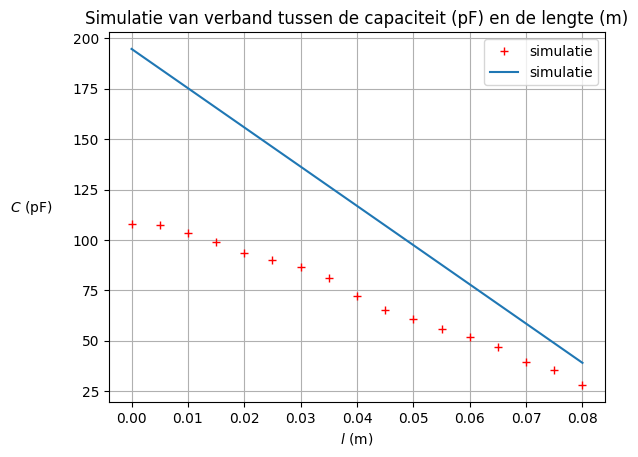

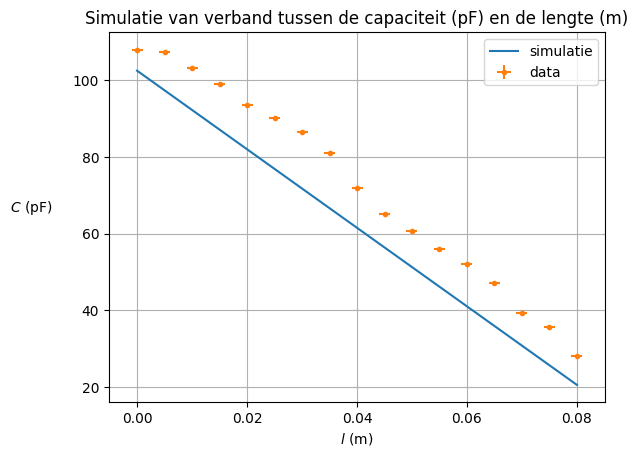

In [4]:
from scipy.optimize import curve_fit
l = np.linspace(0, 0.08, 17) # m
C= np.array([108.0,  107.3, 103.2, 99.0, 93.6, 90.2, 86.4, 81.1, 71.9, 65.2, 60.6, 56.0, 52.0, 47.0, 39.3, 35.6, 28.0] )  #pF



plt.plot(l, C, 'r+', label="simulatie")
plt.plot(l_varieërend, C_varieert, label="simulatie")
plt.title("Simulatie van verband tussen de capaciteit (pF) en de lengte (m)")
plt.xlabel("$l$ (m)")
plt.ylabel("$C$ (pF)", rotation=0, labelpad=30)
plt.legend()
plt.grid()
plt.show()


# tweede run met grotere d 
C_varieert_2 = berekencondensator(epsilon0, epsilon_r_karton, A_varieert, d*1.9) * 10**12
# plot 
plt.plot(l_varieërend, C_varieert_2, label="simulatie")
plt.errorbar(l, C, xerr = 0.001, yerr= 0.2, fmt=". " , label="data")
plt.title("Simulatie van verband tussen de capaciteit (pF) en de lengte (m)")
plt.xlabel("$l$ (m)")
plt.ylabel("$C$ (pF)", rotation=0, labelpad=30)
plt.legend()
plt.grid()
plt.show()

We hebben in de tweede grafiek in de simulatie de dikte vermenigvuldigd met 1.9, omdat in werkelijkheid de dikte tussen de platen groter was door ducktape en verschijvingen.

## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* verbetering 1: De onderste plaat moet vastliggen en niet op een schuin vlak liggen, zodat bij verschuiving van de bovenste plaat het oppervlak goed op dezelfde manier gemeten is.
* verbetering 2: De liniaal moet nauwkeuriger voor een meer accurate kalibratie.

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](setup.jpg)

In [5]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij

## Opdracht 10: Vul hieronder de conclusie in.

Concluderend kunnen we zeggen dat een condensator van twee platen goed bruikbaar is als een liniaal om afstanden te meten. De capacaciteit kan erg nauwkeurig worden bepaald waar dan vervolgens de afstand mee bepaald kan worden. Het kan nog nauwkeuriger worden door een nauwkeurigere liniaal te gebruiken en door de onderplaat van de opstelling strakker op zijn plek te houden. In de eerste plot was een duidelijke afwijking. Dit kwam door een afwijking van de dikte tussen de condensatorplaten ten opzichte van de door ons verwachtte waarde. Toen deze was aangepast werd de afwijking veel minder.

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.

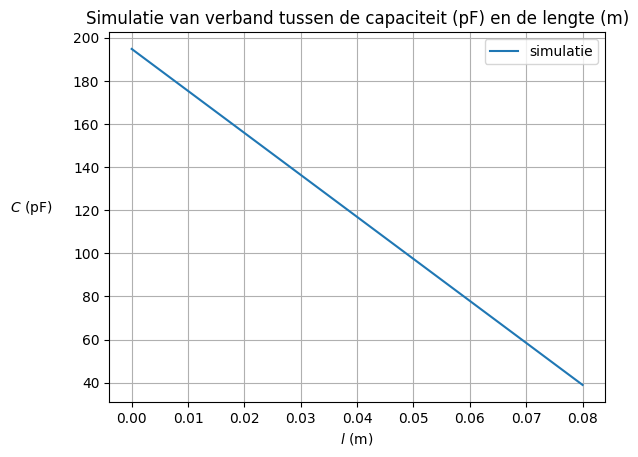

In [6]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.
import matplotlib.pyplot as plt
import numpy as np
# we gaan het effectieve oppervlak varieeren door de lengte te varieeren.
l = 0.1
l_varieërend = np.linspace(0, 0.08, 16) # m
b = 0.1     # m
A_varieert = b *( 0.1-l_varieërend)

# functie
C_varieert = berekencondensator(epsilon0, epsilon_r_karton, A_varieert, d) * 10**12
# plot 
plt.plot(l_varieërend, C_varieert, label="simulatie")
plt.title("Simulatie van verband tussen de capaciteit (pF) en de lengte (m)")
plt.xlabel("$l$ (m)")
plt.ylabel("$C$ (pF)", rotation=0, labelpad=30)
plt.legend()
plt.grid()
plt.show()

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
#![drie schetsen](schetsen.jpeg)

##kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 39 |390 |
| gemiddelde capaciteit| 78 |780 |
| maximale capaciteit| 195 |2000 |

![foto sensor](setup.jpg)


kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.

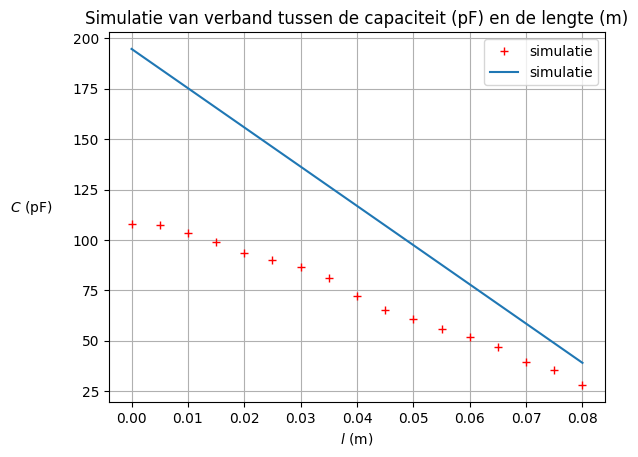

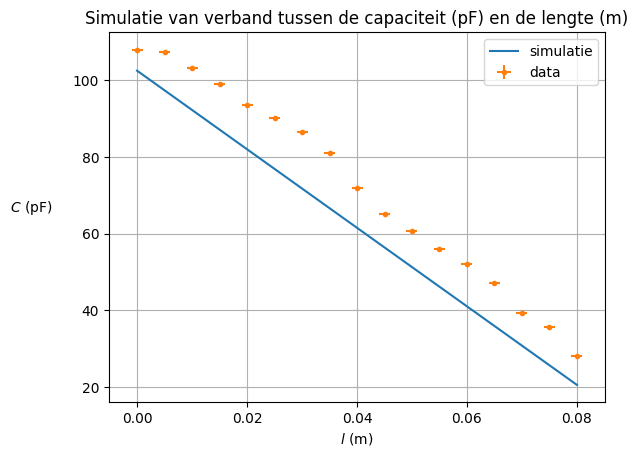

In [7]:
from scipy.optimize import curve_fit
l = np.linspace(0, 0.08, 17) # m
C= np.array([108.0,  107.3, 103.2, 99.0, 93.6, 90.2, 86.4, 81.1, 71.9, 65.2, 60.6, 56.0, 52.0, 47.0, 39.3, 35.6, 28.0] )  #pF



plt.plot(l, C, 'r+', label="simulatie")
plt.plot(l_varieërend, C_varieert, label="simulatie")
plt.title("Simulatie van verband tussen de capaciteit (pF) en de lengte (m)")
plt.xlabel("$l$ (m)")
plt.ylabel("$C$ (pF)", rotation=0, labelpad=30)
plt.legend()
plt.grid()
plt.show()


# tweede run met grotere d 
C_varieert_2 = berekencondensator(epsilon0, epsilon_r_karton, A_varieert, d*1.9) * 10**12
# plot 
plt.plot(l_varieërend, C_varieert_2, label="simulatie")
plt.errorbar(l, C, xerr = 0.001, yerr= 0.2, fmt=". " , label="data")
plt.title("Simulatie van verband tussen de capaciteit (pF) en de lengte (m)")
plt.xlabel("$l$ (m)")
plt.ylabel("$C$ (pF)", rotation=0, labelpad=30)
plt.legend()
plt.grid()
plt.show()


Concluderend kunnen we zeggen dat een condensator van twee platen goed bruikbaar is als een liniaal om afstanden te meten. De capacaciteit kan erg nauwkeurig worden bepaald waar dan vervolgens de afstand mee bepaald kan worden. Het kan nog nauwkeuriger worden door een nauwkeurigere liniaal te gebruiken en door de onderplaat van de opstelling strakker op zijn plek te houden. In de eerste plot was een duidelijke afwijking. Dit kwam door een afwijking van de dikte tussen de condensatorplaten ten opzichte van de door ons verwachtte waarde. Toen deze was aangepast werd de afwijking veel minder.